# 07 · Uncertainty & reliability of the predictions

In virtual screening you act on the top of a ranking, so it matters not just *what* the model predicts but *how trustworthy* each prediction is. This notebook characterises the uncertainty we can measure right now for target 588689:

1. **Structural confidence** Boltz-2 emits per complex (pTM, ipTM, ligand ipTM, pLDDT, PDE) on the ~21k folded compounds — does a confidently-folded pose mean a trustworthy activity call?
2. **The initial score as a probability** — is `score_boltz2` *calibrated* (does a 0.7 mean 70% active), and how sharp/uncertain is it (predictive entropy)?
3. **Selective prediction** — if we only screen the compounds the model is most confident about, does enrichment improve?
4. **Two-head ensemble disagreement** — Boltz-2's affinity module has two heads; their disagreement is an epistemic-uncertainty proxy.
5. **Bootstrap confidence intervals** on the screening metrics themselves.

The post-fine-tune pieces (seed-to-seed variance across the 5 head-FT seeds, and whether FT improves calibration) fill in once the eval scoring finishes.

In [1]:

import glob, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score
BLK="#000000"; ACT="#eb6834"; INA="#2a78d6"; NEU="#555555"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT="/global/scratch/users/sergiomar10/boltzaff"; R=ROOT+"/results/runs/588689"
qc=pd.read_csv(R+"/qc.csv")
qc=qc[np.isfinite(qc.score_boltz2)].copy()
qc["Active"]=qc.Active.astype(int)
# human-readable names for the confidence metrics
CONF={"confidence":"overall confidence","ptm":"pTM (fold)","iptm":"ipTM (interface)",
      "ligand_iptm":"ligand ipTM (pose)","complex_plddt":"complex pLDDT","complex_pde":"complex PDE (dist. error)"}
base_rate=qc.Active.mean()
print(f"folded complexes: {len(qc):,}  actives: {int(qc.Active.sum())} ({100*base_rate:.2f}%)")
print("confidence metrics:", list(CONF))


folded complexes: 21,061  actives: 238 (1.13%)
confidence metrics: ['confidence', 'ptm', 'iptm', 'ligand_iptm', 'complex_plddt', 'complex_pde']


## 1. Distribution of each confidence metric, split by activity
If structural confidence carried activity signal, the active (orange) and inactive (blue) distributions would separate. They largely overlap — the model folds actives and inactives with the same confidence.

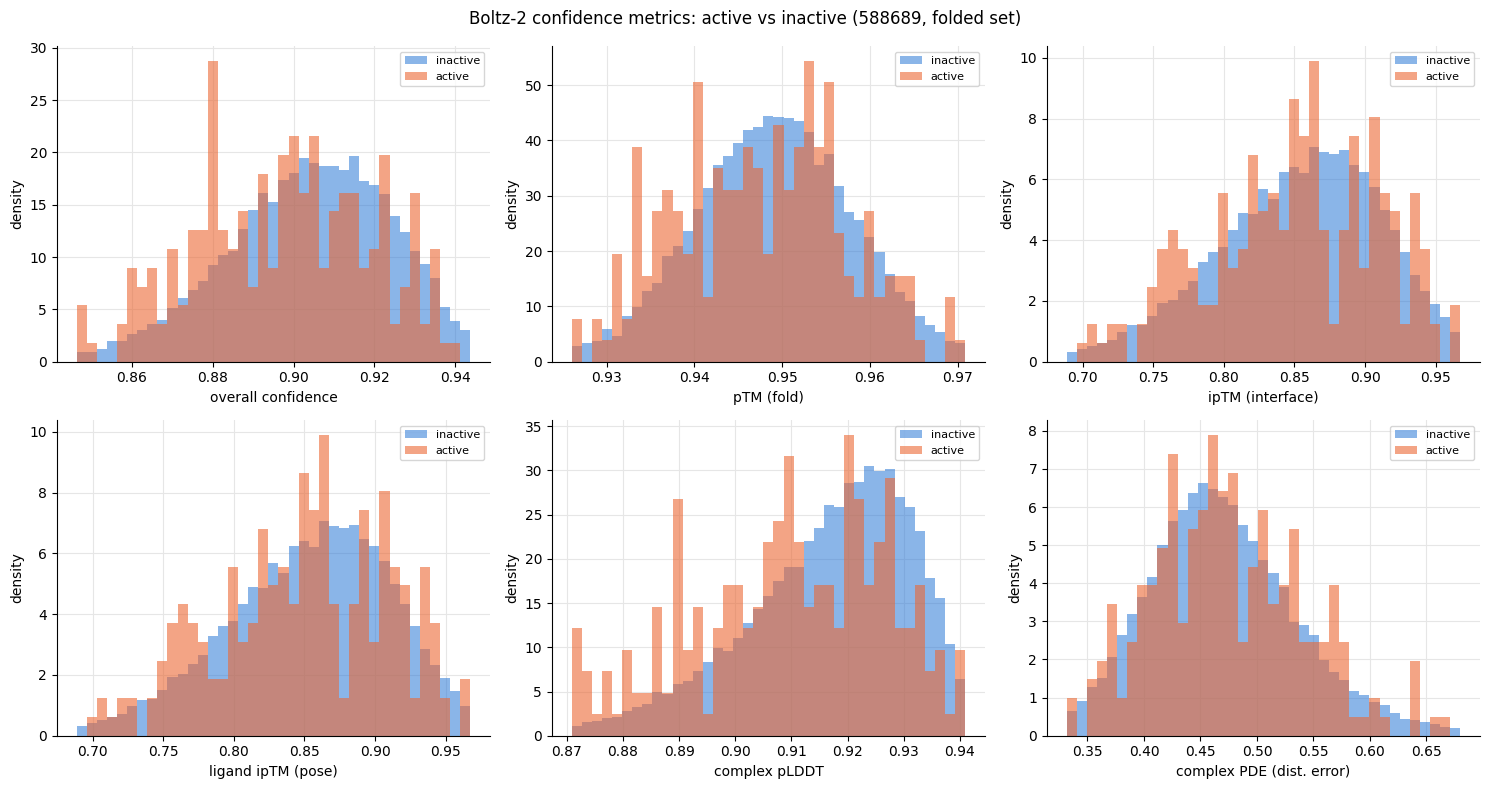

In [2]:
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,(col,lab) in zip(axes.ravel(),CONF.items()):
    a=qc[qc.Active==1][col].dropna(); i=qc[qc.Active==0][col].dropna()
    lo,hi=np.nanpercentile(qc[col],[1,99]); bins=np.linspace(lo,hi,40)
    ax.hist(i,bins=bins,density=True,color=INA,alpha=0.55,label="inactive")
    ax.hist(a,bins=bins,density=True,color=ACT,alpha=0.6,label="active")
    ax.set_xlabel(lab); ax.set_ylabel("density"); ax.legend(fontsize=8)
fig.suptitle("Boltz-2 confidence metrics: active vs inactive (588689, folded set)",fontsize=12)
plt.tight_layout(); plt.show()

## 2. How well does each confidence signal predict activity?
AUROC of each metric as a classifier for the binary label (0.5 = no signal / chance). Structural confidence sits near chance; only the affinity-derived `score_boltz2` separates actives. Confidence in the *pose* is not confidence in the *activity call*.

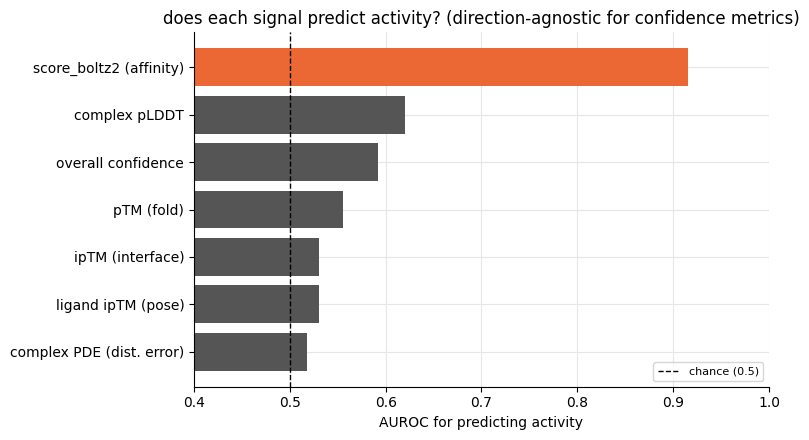

,AUROC
signal,
complex PDE (dist. error),0.518
ligand ipTM (pose),0.530
ipTM (interface),0.530
pTM (fold),0.555
overall confidence,0.592
complex pLDDT,0.620
score_boltz2 (affinity),0.915


In [3]:
rows=[]
for col,lab in CONF.items():
    d=qc[[col,"Active"]].dropna(); s=d[col].values
    au=roc_auc_score(d.Active, s); au=max(au,1-au)  # direction-agnostic separation
    rows.append((lab,au))
d=qc[["score_boltz2","Active"]].dropna()
rows.append(("score_boltz2 (affinity)", roc_auc_score(d.Active,d.score_boltz2)))
au=pd.DataFrame(rows,columns=["signal","AUROC"]).sort_values("AUROC")
fig,ax=plt.subplots(figsize=(8,4.5))
cols=[ACT if "score_boltz2" in s else NEU for s in au.signal]
ax.barh(au.signal,au.AUROC,color=cols)
ax.axvline(0.5,ls="--",color=BLK,lw=1,label="chance (0.5)")
ax.set_xlabel("AUROC for predicting activity"); ax.set_xlim(0.4,1.0); ax.legend(fontsize=8)
ax.set_title("does each signal predict activity? (direction-agnostic for confidence metrics)")
plt.tight_layout(); plt.show()
display(au.set_index("signal").round(3))

## 3. Correlation structure of the confidence metrics
The structural-confidence metrics are highly inter-correlated (they measure one thing: fold/pose quality), and are nearly orthogonal to `score_boltz2`. So confidence gives us essentially one extra axis of information, not five.

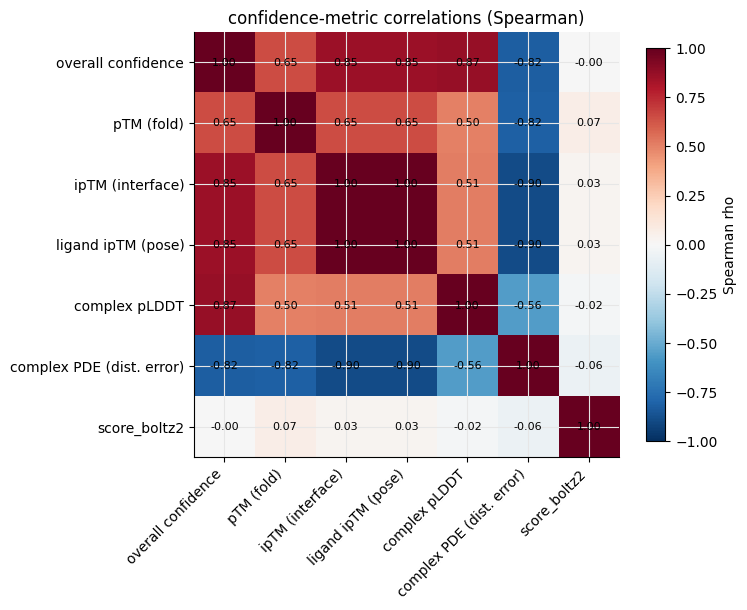

In [4]:
cc=qc[list(CONF)+["score_boltz2"]].corr(method="spearman")
labs=[CONF[c] if c in CONF else "score_boltz2" for c in cc.columns]
fig,ax=plt.subplots(figsize=(7.5,6.5))
im=ax.imshow(cc.values,vmin=-1,vmax=1,cmap="RdBu_r")
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs,rotation=45,ha="right")
ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs)
for i in range(len(labs)):
    for j in range(len(labs)): ax.text(j,i,f"{cc.values[i,j]:.2f}",ha="center",va="center",fontsize=8,color=BLK)
fig.colorbar(im,ax=ax,shrink=0.8,label="Spearman rho")
ax.set_title("confidence-metric correlations (Spearman)"); plt.tight_layout(); plt.show()

## 4. Is `score_boltz2` calibrated as a probability?
Reliability diagram: bin compounds by predicted score, plot the observed active rate in each bin against the mean predicted value. On the diagonal = calibrated. Boltz-2's affinity probability is far above the diagonal — it is a good *ranking* score but massively over-states absolute probability of activity (the active base rate is under 1%).

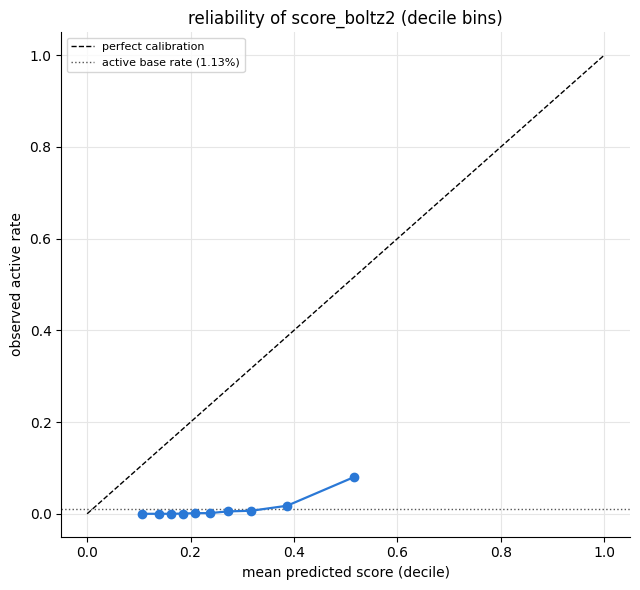

,pred,obs,n
bin,,,
"(0.0404, 0.127]",0.107,0.0000,2107
"(0.127, 0.152]",0.140,0.0000,2106
"(0.152, 0.174]",0.163,0.0000,2106
"(0.174, 0.196]",0.185,0.0005,2106
"(0.196, 0.222]",0.209,0.0014,2106
"(0.222, 0.253]",0.237,0.0014,2106
"(0.253, 0.293]",0.272,0.0052,2105
"(0.293, 0.347]",0.318,0.0066,2107
"(0.347, 0.433]",0.387,0.0176,2106


In [5]:
d=qc[["score_boltz2","Active"]].dropna().copy()
d["bin"]=pd.qcut(d.score_boltz2,10,duplicates="drop")
g=d.groupby("bin",observed=True).agg(pred=("score_boltz2","mean"),obs=("Active","mean"),n=("Active","size"))
fig,ax=plt.subplots(figsize=(6.5,6))
ax.plot([0,1],[0,1],ls="--",color=BLK,lw=1,label="perfect calibration")
ax.axhline(base_rate,ls=":",color=NEU,lw=1,label=f"active base rate ({100*base_rate:.2f}%)")
ax.plot(g.pred,g.obs,marker="o",color=INA,lw=1.6)
ax.set_xlabel("mean predicted score (decile)"); ax.set_ylabel("observed active rate")
ax.set_title("reliability of score_boltz2 (decile bins)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(g.assign(pred=g.pred.round(3),obs=g.obs.round(4)))

## 5. Predictive entropy — how uncertain is each call?
Treating the score as p(active), the per-compound Bernoulli entropy H = -p log2 p -(1-p)log2(1-p) is highest at p=0.5 (maximally uncertain) and low near 0 or 1. Most compounds are confidently predicted inactive; the active-labelled compounds carry more uncertain (higher-entropy) predictions, consistent with the score being over-confident on many decoys.

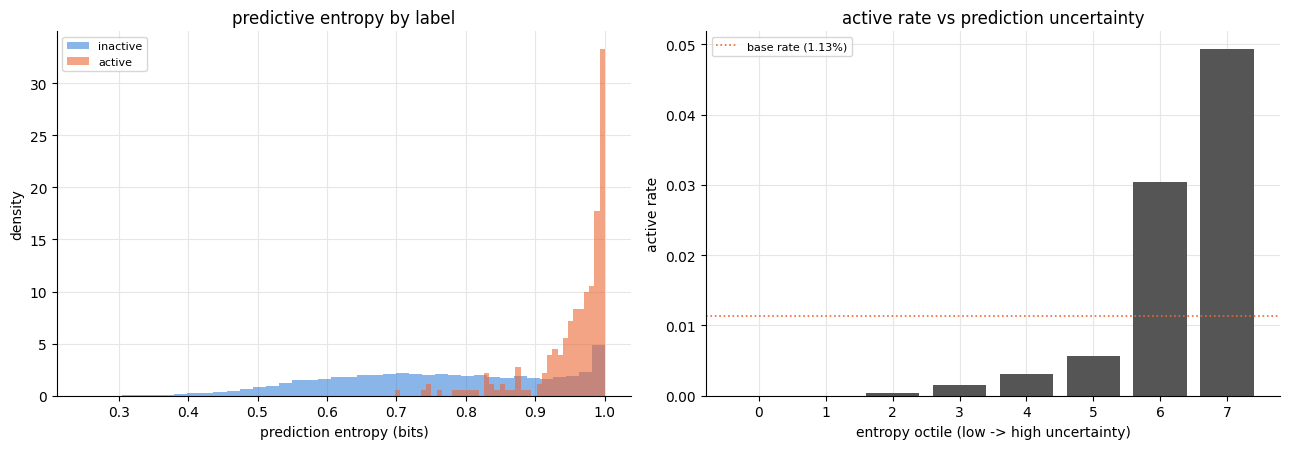

In [6]:
p=qc.score_boltz2.clip(1e-6,1-1e-6).values
H=-(p*np.log2(p)+(1-p)*np.log2(1-p))
qc2=qc.assign(entropy=H)
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
axes[0].hist(qc2[qc2.Active==0].entropy,bins=40,density=True,color=INA,alpha=0.55,label="inactive")
axes[0].hist(qc2[qc2.Active==1].entropy,bins=40,density=True,color=ACT,alpha=0.6,label="active")
axes[0].set_xlabel("prediction entropy (bits)"); axes[0].set_ylabel("density")
axes[0].set_title("predictive entropy by label"); axes[0].legend(fontsize=8)
qc2["ebin"]=pd.qcut(qc2.entropy,8,duplicates="drop")
ge=qc2.groupby("ebin",observed=True).Active.mean()
axes[1].bar(range(len(ge)),ge.values,color=NEU)
axes[1].axhline(base_rate,ls=":",color=ACT,lw=1.2,label=f"base rate ({100*base_rate:.2f}%)")
axes[1].set_xlabel("entropy octile (low -> high uncertainty)"); axes[1].set_ylabel("active rate")
axes[1].set_title("active rate vs prediction uncertainty"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Selective prediction by structural confidence
Risk–coverage view: keep only the most-confident fraction of compounds (by ligand ipTM), re-rank within that subset by `score_boltz2`, and measure early enrichment (active rate in the top 1% of the kept set). If confident poses were more reliable, enrichment would rise as we tighten coverage. It stays flat — a confidence filter does not buy enrichment here.

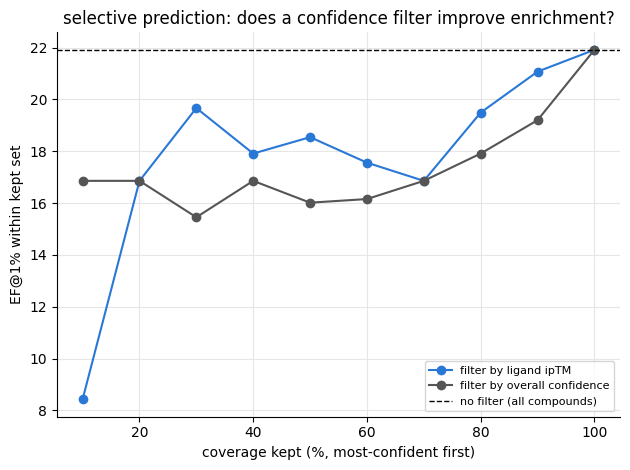

In [7]:
def ef_top1(df):
    k=max(1,int(0.01*len(df))); top=df.nlargest(k,"score_boltz2")
    return top.Active.mean()/max(base_rate,1e-9)
covs=np.linspace(0.1,1.0,10)
for conf,lab,c in [("ligand_iptm","ligand ipTM",INA),("confidence","overall confidence",NEU)]:
    ys=[]
    for cv in covs:
        kept=qc.nlargest(int(cv*len(qc)),conf)
        ys.append(ef_top1(kept))
    plt.plot(100*covs,ys,marker="o",color=c,label=f"filter by {lab}")
plt.axhline(ef_top1(qc),ls="--",color=BLK,lw=1,label="no filter (all compounds)")
plt.xlabel("coverage kept (%, most-confident first)"); plt.ylabel("EF@1% within kept set")
plt.title("selective prediction: does a confidence filter improve enrichment?")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7. Does pose confidence relate to the affinity score?
Hexbin of ligand ipTM (pose confidence) against `score_boltz2` (affinity). Weak relationship — the affinity head's output is not simply a readout of how confident the pose is.

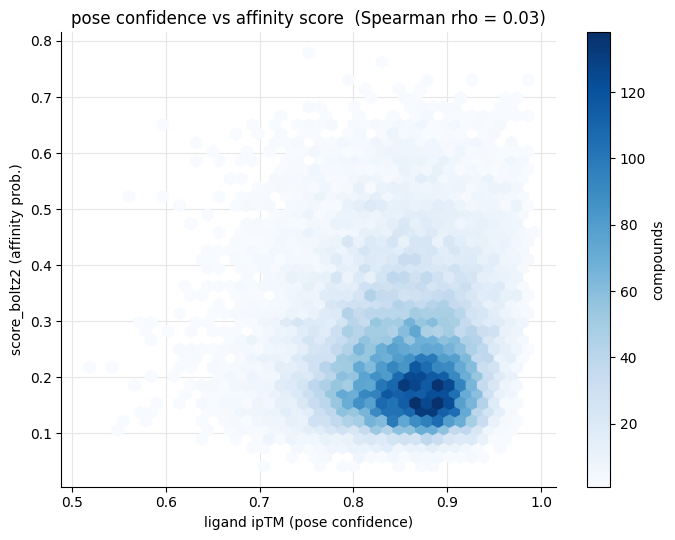

In [8]:
d=qc[["ligand_iptm","score_boltz2"]].dropna()
fig,ax=plt.subplots(figsize=(7,5.5))
hb=ax.hexbin(d.ligand_iptm,d.score_boltz2,gridsize=40,cmap="Blues",mincnt=1)
rho=d.corr(method="spearman").iloc[0,1]
ax.set_xlabel("ligand ipTM (pose confidence)"); ax.set_ylabel("score_boltz2 (affinity prob.)")
ax.set_title(f"pose confidence vs affinity score  (Spearman rho = {rho:.2f})")
fig.colorbar(hb,ax=ax,label="compounds"); plt.tight_layout(); plt.show()

## 8. Enrichment stability across confidence strata
Split the library into quartiles of ligand ipTM and measure the active rate in each. Flat across quartiles = actives are not concentrated among the most confidently-posed compounds, so we cannot safely discard low-confidence poses.

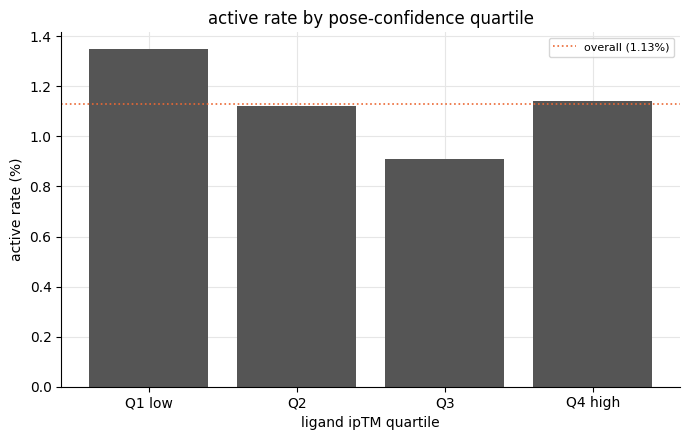

,active_rate,n
q,,
Q1 low,1.348,5266
Q2,1.121,5265
Q3,0.912,5265
Q4 high,1.140,5265


In [9]:
qc3=qc.copy(); qc3["q"]=pd.qcut(qc3.ligand_iptm,4,labels=["Q1 low","Q2","Q3","Q4 high"])
g=qc3.groupby("q",observed=True).agg(active_rate=("Active","mean"),n=("Active","size"))
fig,ax=plt.subplots(figsize=(7,4.5))
ax.bar(range(4),100*g.active_rate.values,color=NEU)
ax.axhline(100*base_rate,ls=":",color=ACT,lw=1.2,label=f"overall ({100*base_rate:.2f}%)")
ax.set_xticks(range(4)); ax.set_xticklabels(g.index)
ax.set_xlabel("ligand ipTM quartile"); ax.set_ylabel("active rate (%)")
ax.set_title("active rate by pose-confidence quartile"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show(); display(g.assign(active_rate=(100*g.active_rate).round(3)))

## 9. Two-head ensemble disagreement (epistemic uncertainty)
Boltz-2's affinity module carries two probability heads (`affinity_probability_binary1/2`). Their disagreement is a model-uncertainty signal that needs no labels. Shown here on the fine-tune's validation predictions (pooled across the 15 head-FT arms). The full-eval version fills in once scoring completes; this confirms the signal is available and behaves sensibly (disagreement peaks for mid-range predictions).

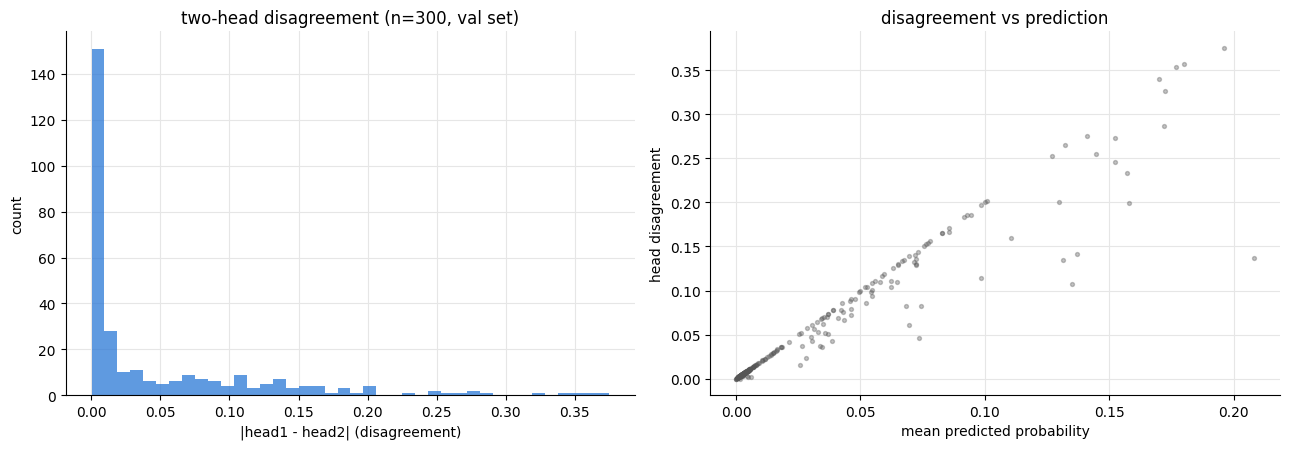

mean disagreement 0.050, 95th pct 0.200


In [10]:
vp=[]
for f in glob.glob(R+"/headft_full/top*_seed*/validation_predictions/val_predictions_epoch_4.csv"):
    try: vp.append(pd.read_csv(f))
    except: pass
if vp:
    v=pd.concat(vp,ignore_index=True)
    v["mean_p"]=0.5*(v.affinity_probability_binary1+v.affinity_probability_binary2)
    v["disagree"]=(v.affinity_probability_binary1-v.affinity_probability_binary2).abs()
    fig,axes=plt.subplots(1,2,figsize=(13,4.6))
    axes[0].hist(v.disagree,bins=40,color=INA,alpha=0.75)
    axes[0].set_xlabel("|head1 - head2| (disagreement)"); axes[0].set_ylabel("count")
    axes[0].set_title(f"two-head disagreement (n={len(v)}, val set)")
    axes[1].scatter(v.mean_p,v.disagree,s=8,alpha=0.35,color=NEU)
    axes[1].set_xlabel("mean predicted probability"); axes[1].set_ylabel("head disagreement")
    axes[1].set_title("disagreement vs prediction"); plt.tight_layout(); plt.show()
    print(f"mean disagreement {v.disagree.mean():.3f}, 95th pct {v.disagree.quantile(.95):.3f}")
else:
    print("no validation predictions found yet")

## 10. Bootstrap confidence intervals on the screening metrics
Uncertainty on the *metrics themselves*. 95% bootstrap intervals (from `cpu_ci_588689.csv`) for the label-free / CPU reference methods. Wide intervals — with under 1% actives, single-run metric differences are noisy, which is exactly why we run multiple seeds and report spread for head-FT.

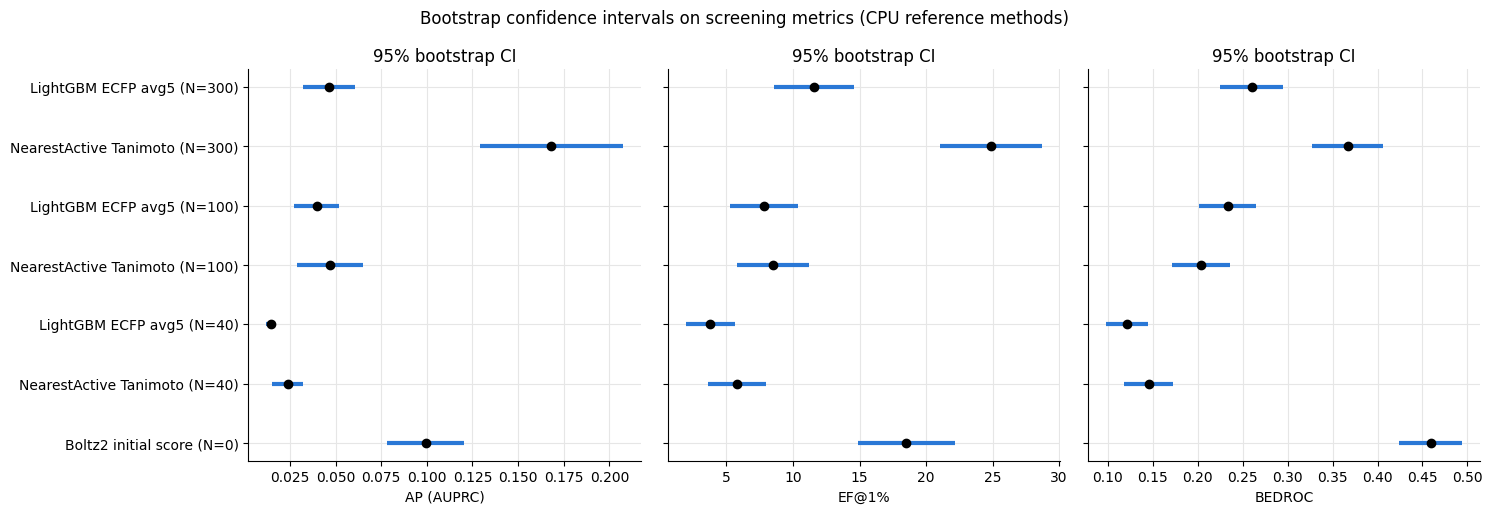

,method,n_train,ap_lo,ap_hi,ef1_lo,ef1_hi,bedroc_lo,bedroc_hi
0,Boltz2_initial_score,0,0.078,0.121,14.867,22.190,0.424,0.494
1,NearestActive_Tanimoto,40,0.015,0.032,3.579,7.950,0.118,0.172
2,LightGBM_ECFP_avg5,40,0.012,0.017,1.949,5.626,0.097,0.144
3,NearestActive_Tanimoto,100,0.029,0.065,5.792,11.168,0.171,0.235
4,LightGBM_ECFP_avg5,100,0.028,0.052,5.261,10.351,0.201,0.265
5,NearestActive_Tanimoto,300,0.129,0.207,21.034,28.752,0.327,0.406
6,LightGBM_ECFP_avg5,300,0.032,0.061,8.591,14.564,0.225,0.295


In [11]:
ci=pd.read_csv(ROOT+"/results/analysis/cpu_ci_588689.csv")
ci["label"]=ci.method.str.replace("_"," ")+" (N="+ci.n_train.astype(str)+")"
panels=[("ap_lo","ap_hi","AP (AUPRC)"),("ef1_lo","ef1_hi","EF@1%"),("bedroc_lo","bedroc_hi","BEDROC")]
fig,axes=plt.subplots(1,3,figsize=(15,1.0+0.6*len(ci)))
for ax,(lo,hi,ttl) in zip(axes,panels):
    mid=0.5*(ci[lo]+ci[hi])
    ax.hlines(range(len(ci)),ci[lo],ci[hi],color=INA,lw=3)
    ax.plot(mid,range(len(ci)),"o",color=BLK)
    ax.set_yticks(range(len(ci))); ax.set_yticklabels(list(ci.label) if ax is axes[0] else [])
    ax.set_xlabel(ttl); ax.set_title("95% bootstrap CI")
fig.suptitle("Bootstrap confidence intervals on screening metrics (CPU reference methods)",fontsize=12)
plt.tight_layout(); plt.show(); display(ci.drop(columns="label").round(3))

## 11. Coverage–enrichment (risk–coverage) curve for the ranking
Reading down the `score_boltz2` ranking, the cumulative active rate (precision) at each coverage depth. Steep early section = strong early enrichment; it decays toward the base rate as coverage grows. This is the operating-point view a screener actually uses to decide how deep to test.

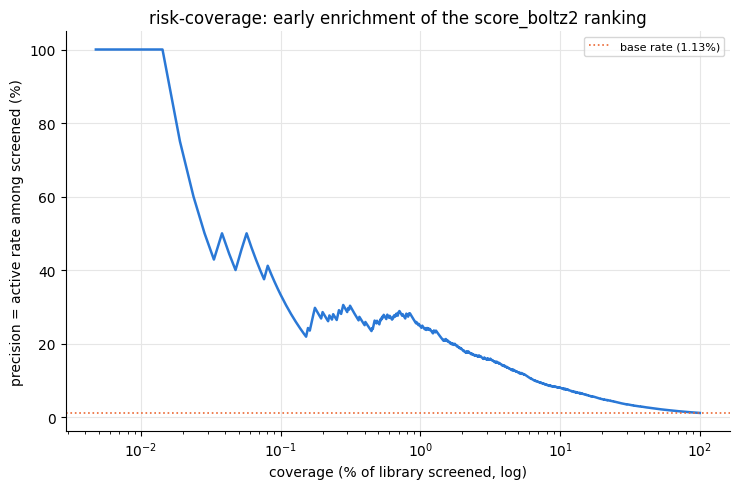

In [12]:
d=qc.sort_values("score_boltz2",ascending=False).reset_index(drop=True)
cum=d.Active.cumsum().values/(np.arange(len(d))+1)
cov=100*(np.arange(len(d))+1)/len(d)
fig,ax=plt.subplots(figsize=(7.5,5))
ax.plot(cov,100*cum,color=INA,lw=1.8)
ax.axhline(100*base_rate,ls=":",color=ACT,lw=1.2,label=f"base rate ({100*base_rate:.2f}%)")
ax.set_xscale("log"); ax.set_xlabel("coverage (% of library screened, log)")
ax.set_ylabel("precision = active rate among screened (%)")
ax.set_title("risk-coverage: early enrichment of the score_boltz2 ranking"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

- **Structural confidence is not activity confidence.** pTM/ipTM/ligand-ipTM/pLDDT separate actives from inactives at roughly chance AUROC, are highly inter-correlated, and give flat active rates across quartiles. A confidence filter does not improve early enrichment (selective-prediction curve stays flat).
- **`score_boltz2` ranks well but is not calibrated** — it sits far above the reliability diagonal and over-states absolute activity probability given the <1% base rate. Predictive entropy is higher for the active-labelled compounds.
- **Two-head disagreement** is available as a label-free epistemic-uncertainty signal and behaves sensibly; the full-eval version fills in with scoring.
- **Metric-level uncertainty is large** (wide bootstrap CIs at <1% actives), motivating the multi-seed head-FT protocol and reporting spread rather than single runs.

Reserved for when eval scoring completes: seed-to-seed variance of head-FT EF@1%/AP across the 5 seeds, and whether fine-tuning improves calibration relative to No-FT.